In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

### Cap 3.5 - Filtros espaciais de suavização

##### 3.5.1 - Filtros Lineares (Média)

Filtro de média:

$ R=\frac{1}{m}\sum_{i=1-\frac{m-1}{2}}^{i+\frac{m-1}{2}}Z_i$

Filtro de mediana:

$ g(x,y)=\frac{\sum_{s=-a}^{a}\sum_{t=-b}^{b}w(s,t)f(x+s,y+t)}{\sum_{s=-a}^{a}\sum_{t=-b}^{b}w(s,t)}$

### Cap 3.6 - Filtros espaciais de aguçamento

##### 3.6.1 - Fundamentos

Derivada de primeira ordem de uma função unidimensional f(x):

$ \frac{\partial f}{\partial x} = f(x+1)-f(x) $

Derivada se segunda ordem de f(x):

$ \frac{\partial^{2} f}{\partial x^{2}} = f(x+1)+f(x-1)-2f(x) $

In [2]:
def _check_m(m: int):
    if m < 1 or m % 2 == 0:
        raise ValueError("m deve ser ímpar e maior ou igual 1")

def _conv1d_along_axis(a: np.ndarray, kernel: np.ndarray, axis: int, pad_mode: str):
    pad = len(kernel) // 2

    pad_width = [(0,0)] * a.ndim
    pad_width[axis] = (pad, pad)
    ap = np.pad(a, pad_width=pad_width, mode=pad_mode)

    return np.apply_along_axis(lambda v: np.convolve(v, kernel, mode="valid"), axis, ap)

def mean_filter_2d(img: np.ndarray, m: int, pad_mode: str = "reflect") -> np.ndarray:
    """
    Média móvel 2D mxm. Se img for RGB (H,W,3), filtra canal a canal.
    """
    _check_m(m)
    kernel = np.ones(m, dtype=float) / m  # separável: 1D horizontal + 1D vertical

    if img.ndim == 2:
        # 2D: HxW
        out = _conv1d_along_axis(img.astype(float), kernel, axis=1, pad_mode=pad_mode)  # horiz
        out = _conv1d_along_axis(out,             kernel, axis=0, pad_mode=pad_mode)    # vert
        return out
    elif img.ndim == 3 and img.shape[2] in (3,4):
        # 3D: HxWxC -> processa cada canal
        channels = []
        for c in range(img.shape[2]):
            ch = img[..., c].astype(float)
            ch = _conv1d_along_axis(ch, kernel, axis=1, pad_mode=pad_mode)
            ch = _conv1d_along_axis(ch, kernel, axis=0, pad_mode=pad_mode)
            channels.append(ch)
        return np.stack(channels, axis=2)
    else:
        raise ValueError("Imagem deve ser 2D (HxW) ou 3D (HxWxC).")

def threshold_manual(img, T):
    """
    Aplica limiarização binária com limiar T.
    - img: imagem em escala de cinza (0-1 ou 0-55)
    - T: valor de limiar (float ou int)
    Retorna imagem binária (0 e 1)
    """
    img = np.asarray(img, dtype=float)
    if img.max() > 1:  # normaliza para [0,1] se necessário
        img = img / 255.0
    binary = (img >= T).astype(float)
    return binary

In [3]:
img_hubble = Image.open("./../../CH03_Original_Images/Fig0334(a)(hubble-original).tif").convert("L")
img_board = Image.open("./../../CH03_Original_Images/Fig0335(a)(ckt_board_saltpep_prob_pt05).tif").convert("L")
img_moon = Image.open("./../../CH03_Original_Images/Fig0338(a)(blurry_moon).tif").convert("L")

Imagem Hubble (3.34)

In [4]:
img_hubble_array = np.array(img_hubble)
print(f"{type(img_hubble_array)}, {type(img_hubble)}")
print(f"{img_hubble_array.shape}, {img_hubble.size}")

<class 'numpy.ndarray'>, <class 'PIL.Image.Image'>
(528, 485), (485, 528)


In [5]:
# Normalização 
img_hubble_normalized = img_hubble_array.astype(np.float32) / 255.0

m = 15
hubble_image_filtered = mean_filter_2d(img_hubble_normalized, m) * 255.0
hubble_image_thresh = threshold_manual(hubble_image_filtered, 0.3)

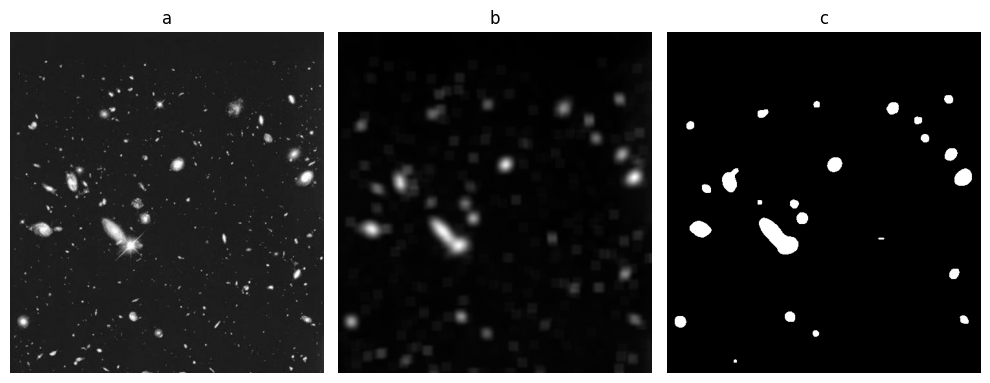

In [79]:
fig, axes = plt.subplots(1,3, figsize=(10,5))

axes[0].imshow(img_hubble_array, cmap="gray")
axes[0].set_title('a')
axes[0].axis("off")

axes[1].imshow(hubble_image_filtered, cmap="gray")
axes[1].set_title('b')
axes[1].axis("off")

axes[2].imshow(hubble_image_thresh, cmap="gray")
axes[2].set_title('c')
axes[2].axis("off")

plt.tight_layout()
plt.savefig("results/panel_figure_3.34.tif")
plt.show()

Imagem Board (3.35)

In [7]:
img_board_array = np.array(img_board)
print(f"{type(img_board_array)}, {type(img_board)}")
print(f"{img_board_array.shape}, {img_board.size}")

<class 'numpy.ndarray'>, <class 'PIL.Image.Image'>
(440, 455), (455, 440)


In [8]:
from numpy.lib.stride_tricks import sliding_window_view

def median_filter_2d(img: np.ndarray, m: int, *, pad_mode: str = "reflect") -> np.ndarray:
    """
    Filtro mediana 2D mxm.
    - img HxW (grayscale) ou HxWxC (RGB/RGBA)
    - Aplica por canal se houver 3º eixo.
    """
    _check_m(m)
    img = np.asarray(img, dtype=float)

    def _median2d_gray(gray: np.ndarray) -> np.ndarray:
        pad = m // 2
        gp = np.pad(gray, pad_width=pad, mode=pad_mode)
        # janelas (H, W, m, m)
        win = sliding_window_view(gp, (m, m))
        return np.median(win, axis=(-1, -2))

    if img.ndim == 2:
        return _median2d_gray(img)
    elif img.ndim == 3 and img.shape[2] in (3, 4):
        chans = [ _median2d_gray(img[..., c]) for c in range(img.shape[2]) ]
        return np.stack(chans, axis=2)
    else:
        raise ValueError("Imagem deve ser 2D (HxW) ou 3D (HxWxC).")


In [9]:
# Normalização 
img_board_normalized = img_board_array.astype(np.float32) / 255.0

m = 3
board_image_mean_filtered = mean_filter_2d(img_board_normalized, m) * 255.0
board_image_median_filtered = median_filter_2d(img_board_normalized, m) * 255.0

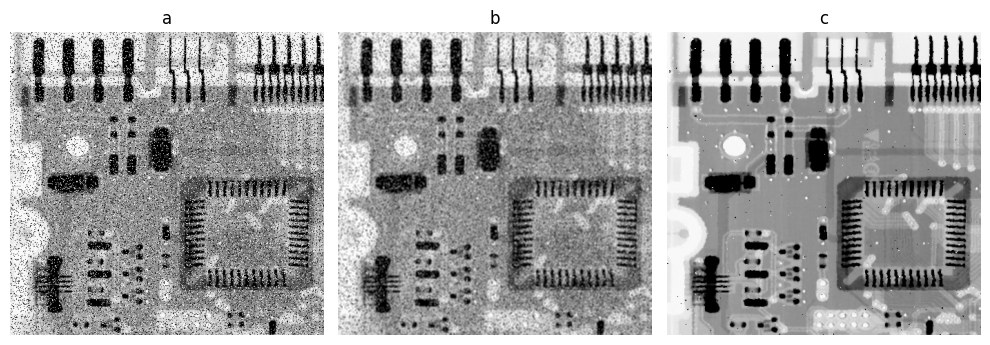

In [78]:
fig, axes = plt.subplots(1,3, figsize=(10,5))

axes[0].imshow(img_board_array, cmap="gray")
axes[0].set_title('a')
axes[0].axis("off")

axes[1].imshow(board_image_mean_filtered, cmap="gray")
axes[1].set_title('b')
axes[1].axis("off")

axes[2].imshow(board_image_median_filtered, cmap="gray")
axes[2].set_title('c')
axes[2].axis("off")

plt.tight_layout()
plt.savefig("results/panel_figure_3.35.tif")
plt.show()

Imagem Blurry Moon (3.38)

In [11]:
img_moon_array = np.array(img_moon)
print(f"{type(img_moon_array)}, {type(img_moon)}")
print(f"{img_moon_array.shape}, {img_moon.size}")

<class 'numpy.ndarray'>, <class 'PIL.Image.Image'>
(540, 466), (466, 540)


Implementação do Laplaciano (sem ajuste)

$ \nabla2 f = f(x + 1, y) + f(x −1, y) + f(x ,y + 1) + f(x ,y −1) − 4f(x ,y ) $

Com ajuste:

$ g(x, y) = f(x, y) + c[\nabla^2f(x,y)] $

In [26]:
LAPLACE4 = np.array([[0, 1, 0],
                     [1,-4, 1],
                     [0, 1, 0]], dtype=float)

LAPLACE8 = np.array([[1, 1, 1],
                     [1,-8, 1],
                     [1, 1, 1]], dtype=float)

def laplacian_numpy(img, laplace, pad_mode="reflect"):
    """img: HxW ou HxWxC; retorna float64"""
    img = np.asarray(img, dtype=float)
    if img.ndim == 2:      # grayscale
        return _conv2_valid_pad(img, laplace, pad_mode)
    elif img.ndim == 3:    # RGB/RGBA
        chans = [ _conv2_valid_pad(img[...,c], laplace, pad_mode) for c in range(img.shape[2]) ]
        return np.stack(chans, axis=2)
    else:
        raise ValueError("Imagem deve ser 2D (HxW) ou 3D (HxWxC).")

def _conv2_valid_pad(gray, kernel, pad_mode):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    gp = np.pad(gray, ((ph,ph),(pw,pw)), mode=pad_mode)
    # janelas (H, W, kh, kw)
    win = sliding_window_view(gp, (kh, kw))
    return np.tensordot(win, kernel, axes=((-1,-2),(1,0)))  # mesma forma de gray

In [72]:
# Normalização 
img_moon_normalized = img_moon_array.astype(np.float32) / 255.0
img_moon_float = img_moon_array.astype(np.float32)

moon_image_laplacian_4 = laplacian_numpy(img_moon_normalized, laplace=LAPLACE4) * 255.0 #np.float32
moon_image_laplacian_8 = laplacian_numpy(img_moon_normalized, laplace=LAPLACE8) * 255.0 #np.float32
moon_image_laplacian_adjust = img_moon_float - moon_image_laplacian_4
moon_image_laplacian_adjust_8 = img_moon_float - moon_image_laplacian_8

In [73]:
# 1. Aplica o deslocamento de 128
moon_image_laplacian_4_deslocado = moon_image_laplacian_4 + 128

# 2. Clipa e converte para uint8 para exibição (Figura C)
moon_image_laplacian_4_deslocado = np.clip(moon_image_laplacian_4_deslocado, 0, 255).astype(np.uint8)

In [74]:
# Limitar (Clip) e Converter para 8-bit (uint8) para visualização, pois os valores podem estar
# fora da faixa [0, 255] após a subtração

moon_image_adjust_4 = np.clip(moon_image_laplacian_adjust, 0, 255).astype(np.uint8)
#moon_image_laplacian_4 = np.clip(moon_image_laplacian_4, 0, 255).astype(np.uint8)
moon_image_laplacian_4_without_adjust = np.clip(moon_image_laplacian_4, 0, 255).astype(np.uint8)
moon_image_adjust_8 = np.clip(moon_image_laplacian_adjust_8, 0, 255).astype(np.uint8)

In [ ]:
print("dtypes das imagens:")

print(img_moon_array.dtype)

print(moon_image_laplacian_4_without_adjust.dtype)

print(moon_image_adjust_8.dtype)

print(moon_image_adjust_4.dtype)

print(moon_image_adjust_8.dtype)


Dtypes das imagens:
uint8
uint8
uint8
uint8
uint8


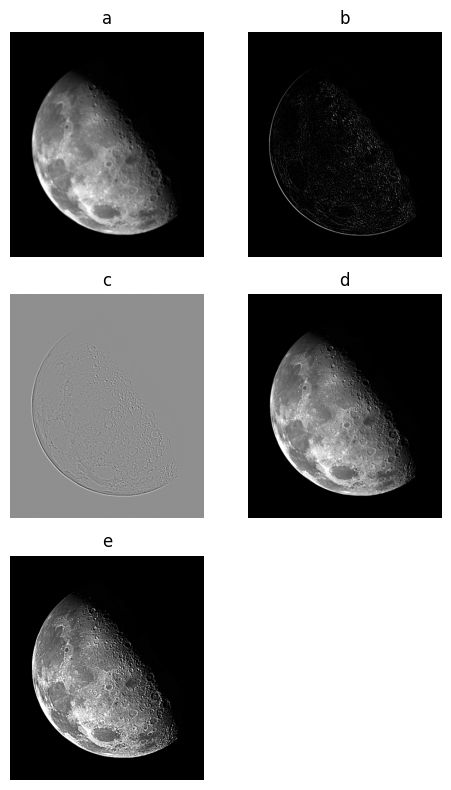

In [77]:
fig, axes = plt.subplots(3,2, figsize=(5,8))

axes[0,0].imshow(img_moon_array, cmap="gray")
axes[0,0].set_title('a')
axes[0,0].axis("off")

axes[0,1].imshow(moon_image_laplacian_4_without_adjust, cmap="gray")
axes[0,1].set_title('b')
axes[0,1].axis("off")

axes[1,0].imshow(moon_image_laplacian_4_deslocado, cmap="gray")
axes[1,0].set_title('c')
axes[1,0].axis("off")

axes[1,1].imshow(moon_image_adjust_4, cmap="gray")
axes[1,1].set_title('d')
axes[1,1].axis("off")

axes[2,0].imshow(moon_image_adjust_8, cmap="gray")
axes[2,0].set_title('e')
axes[2,0].axis("off")

axes[2, 1].set_visible(False)

plt.tight_layout()
plt.savefig("results/panel_figure_3.38.tif")
plt.show()